# Занятие 03. Дерево решений по внешнему набору данных: Processed Data for EV Powertrain Efficiency, Mendeley Data

## Теоретический блок

Классификация (classification) - задача отнесения наблюдения к одному из
заранее заданных классов. В данном блокноте целевая переменная
`is_allowed` кодирует условно допустимый режим: КПД электропривода не ниже учебного порога.
Дерево решений (Decision Tree) используется как интерпретируемая модель,
поскольку его правила можно записать в виде пороговых инженерных условий.

## Описание источника и учебная гипотеза

Набор описывает движение электрического транспортного средства и расчетную эффективность его электропривода. Он демонстрирует переход от траекторных данных к энергетическим показателям.

Структура данных: Feature-CSV содержит скорость транспортного средства, ускорение, уклон, скорость и момент электродвигателя. Diagnostics-CSV хранит дату, координаты, расчетные показатели эффективности, суммарную силу сопротивления, механическую мощность и порог классификации эффективности.

Особенность обработки: Для этого источника особенно важна защита от прокси-утечки: drivetrain_efficiency близко связан с motor_efficiency и не должен использоваться как строгий признак регрессии целевого КПД двигателя.

Предупреждение об интерпретации: Целевая эффективность в источнике является расчетной величиной; выводы следует трактовать как анализ траекторных данных, а не как стендовое измерение КПД отдельного двигателя.

Семантика классификационной метки: `is_allowed` является учебной меткой низкого КПД: 1 означает, что `motor_efficiency` не ниже выбранного квартильного порога; это не аварийная классификация и не нормативный допуск.

Учебная гипотеза занятия: дерево решений должно быть не только точным, но и
объяснимым. Поэтому оцениваются не только accuracy, но и матрица ошибок,
полнота критического класса, влияние глубины дерева, распределение ошибок по
диагностическим меткам и риск утечки данных.

## Метрики классификации

Матрица ошибок (confusion matrix) сопоставляет истинный класс и предсказанный
класс. Для бинарной классификации используются четыре величины: TP, TN, FP и
FN. Доля правильных ответов (accuracy) вычисляется как

$$accuracy = \frac{TP + TN}{TP + TN + FP + FN}.$$

Полнота (recall) для выбранного класса показывает, какая доля объектов этого
класса найдена моделью:

$$recall = \frac{TP}{TP + FN}.$$

Точность положительных предсказаний (precision) показывает, какая доля
предсказаний выбранного класса является правильной:

$$precision = \frac{TP}{TP + FP}.$$

F1-мера (F1-score) является гармоническим средним precision и recall:

$$F1 = \frac{2 \cdot precision \cdot recall}{precision + recall}.$$

В инженерной диагностике особое внимание уделяется ошибке, при которой
недопустимый или отказный режим распознан как допустимый.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
TIME_KIND = "Unix-время в секундах, полученное из столбца DateTime"
DATASET_ID = "mendeley_ev_powertrain_efficiency"
DATASET_TITLE = "Processed Data for EV Powertrain Efficiency, Mendeley Data"
ALLOW_BASE_FALLBACK = False

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        if not ALLOW_BASE_FALLBACK:
            raise FileNotFoundError(
                "Не найдены подготовленные внешние CSV. Выполните "
                "`venv/bin/python scripts/prepare_external_datasets.py`. "
                "Для аварийной демонстрации можно вручную установить "
                "ALLOW_BASE_FALLBACK = True, но тогда выводы блокнота будут "
                "относиться к базовому синтетическому набору, а не к внешнему источнику."
            )
        print(
            "Предупреждение: используется базовый синтетический CSV. "
            "Содержательные выводы по внешнему источнику в этом режиме недействительны."
        )
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25, target_column=None):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]

    if target_column is None or target_column not in data.columns or data[target_column].nunique() < 2:
        return train_idx, test_idx, test_groups

    def _has_two_classes(index):
        return data.loc[index, target_column].nunique() >= 2

    if _has_two_classes(train_idx) and _has_two_classes(test_idx):
        return train_idx, test_idx, test_groups

    selected_groups = []
    for class_value in sorted(data[target_column].dropna().unique()):
        class_groups = np.array(sorted(data.loc[data[target_column] == class_value, group_column].dropna().unique()))
        class_test_count = max(1, int(np.ceil(len(class_groups) * test_share)))
        selected_groups.extend(class_groups[-class_test_count:].tolist())
    test_groups = np.array(sorted(set(selected_groups)))
    test_mask = data[group_column].isin(test_groups)
    train_idx = data.index[~test_mask]
    test_idx = data.index[test_mask]
    if not (_has_two_classes(train_idx) and _has_two_classes(test_idx)):
        raise ValueError(
            "Групповое разбиение не содержит оба класса в обучающей и тестовой "
            "выборках. Проверьте profile_id или правило формирования is_allowed."
        )
    return train_idx, test_idx, test_groups


def validate_features(features, forbidden, context):
    leaked = set(features) & set(forbidden)
    if leaked:
        raise AssertionError(
            f"Обнаружена утечка данных в {context}: {sorted(leaked)}"
        )
    return list(features)


def existing_columns(data, columns):
    result = []
    for column in columns:
        if column in data.columns and column not in result:
            result.append(column)
    return result


def compact_numeric_profile(data, columns):
    selected = data[existing_columns(data, columns)].select_dtypes(include=[np.number])
    rows = []
    for column in selected.columns:
        series = selected[column]
        rows.append(
            dict(
                column=column,
                missing_count=int(series.isna().sum()),
                missing_share=float(series.isna().mean()),
                unique_count=int(series.nunique(dropna=True)),
                minimum=float(series.min()),
                q25=float(series.quantile(0.25)),
                median=float(series.median()),
                q75=float(series.quantile(0.75)),
                maximum=float(series.max()),
                mean=float(series.mean()),
                std=float(series.std()),
            )
        )
    return pd.DataFrame(rows).set_index("column")


def print_missing_interpretation(data):
    missing_share = data.isna().mean().sort_values(ascending=False)
    nonzero = missing_share[missing_share > 0]
    if nonzero.empty:
        print("Интерпретация: пропуски не обнаружены. Для учебной работы это означает, что можно сосредоточиться на диапазонах, группах и риске утечки данных.")
    else:
        print("Интерпретация: обнаружены пропуски. Перед моделированием необходимо выбрать способ обработки и объяснить его физический смысл.")
        print(nonzero.head(10).to_string())


def print_group_interpretation(data, group_column):
    if group_column not in data.columns:
        print("Групповой столбец отсутствует. Следует явно обосновать выбранный способ разбиения данных.")
        return
    group_counts = data[group_column].value_counts()
    print(f"Число групп: {group_counts.shape[0]}.")
    print(f"Минимальный размер группы: {group_counts.min()}.")
    print(f"Максимальный размер группы: {group_counts.max()}.")
    print(
        "Интерпретация: если наблюдения внутри одной группы близки по происхождению, "
        "то строки одной группы нельзя произвольно делить между обучением и тестом."
    )


def print_top_correlations(data, columns, target_column, top_n=5):
    candidate_columns = [column for column in columns if column != target_column] + [target_column]
    usable_columns = existing_columns(data, candidate_columns)
    if target_column not in usable_columns:
        print(f"Целевая переменная {target_column} отсутствует.")
        return pd.DataFrame()
    corr = data[usable_columns].corr(numeric_only=True)[target_column].drop(target_column, errors="ignore")
    result = corr.reindex(corr.abs().sort_values(ascending=False).index).head(top_n).to_frame("correlation")
    print(
        "Интерпретация: высокая корреляция показывает сильную линейную связь, "
        "но не доказывает причинность. Также необходимо проверить, не является ли "
        "признак производным от целевой переменной."
    )
    return result


def interpret_regression_metrics(metrics):
    best_model = metrics["R2"].idxmax()
    best_r2 = metrics.loc[best_model, "R2"]
    best_mae = metrics.loc[best_model, "MAE"]
    print(f"Лучшая модель по R2: {best_model}.")
    print(f"R2 = {best_r2:.4f}; MAE = {best_mae:.4f}.")
    print(
        "Интерпретация: MAE показывает средний модуль ошибки в единицах целевой "
        "переменной. R2 показывает долю объясненной дисперсии относительно "
        "модели среднего значения. Высокий R2 должен дополнительно проверяться "
        "на утечку данных и устойчивость к способу разбиения."
    )


def interpret_split_comparison(metrics):
    if {"group_holdout", "random_split"}.issubset(metrics.index):
        delta = metrics.loc["random_split", "R2"] - metrics.loc["group_holdout", "R2"] if "R2" in metrics.columns else np.nan
        print(f"Разница random_split - group_holdout по R2: {delta:.4f}.")
        print(
            "Интерпретация: если случайное разбиение существенно лучше группового, "
            "это может указывать на информационную близость соседних наблюдений и "
            "завышение качества при случайном перемешивании."
        )
    else:
        print("Сравнение разбиений недоступно.")


def interpret_classification_metrics(metrics):
    if "strict_decision_tree" in metrics.index:
        row = metrics.loc["strict_decision_tree"]
        print(f"Accuracy строгого дерева: {row['accuracy']:.4f}.")
        print(f"Recall недопустимого класса: {row['recall_not_allowed']:.4f}.")
        print(f"Доля ложных разрешений: {row['dangerous_false_allowed_rate']:.4f}.")
        print(
            "Интерпретация: для инженерной безопасности recall недопустимого класса "
            "и доля ложных разрешений важнее, чем одна общая accuracy."
        )


def interpret_depth_metrics(metrics):
    best_depth = metrics["f1_not_allowed"].idxmax()
    print(f"Наилучшая глубина по F1 недопустимого класса: {best_depth}.")
    print(
        "Интерпретация: рост глубины увеличивает гибкость дерева, но может привести "
        "к переобучению. Следует выбирать не максимальную глубину, а глубину, которая "
        "дает приемлемый баланс качества и интерпретируемости."
    )


def plot_missingness(data, title):
    missing_share = data.isna().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_share))))
    ax.barh(missing_share.index[::-1], missing_share.values[::-1], color="#4c78a8")
    ax.set_xlabel("Доля пропусков")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_boxplots(data, columns, title):
    selected = existing_columns(data, columns)
    if not selected:
        print("Нет доступных столбцов для построения диаграмм размаха.")
        return
    fig, axes = plt.subplots(1, len(selected), figsize=(max(10, 2.2 * len(selected)), 4))
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, selected):
        ax.boxplot(data[column].dropna(), vert=True)
        ax.set_title(column, rotation=20)
        ax.set_ylabel("Значение")
    plt.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()


def plot_time_or_group_profile(data, value_column, title):
    if value_column not in data.columns:
        print(f"Столбец {value_column} отсутствует.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    if TIME_COLUMN in data.columns:
        sample = data.sort_values([GROUP_COLUMN, TIME_COLUMN]).head(800)
        axes[0].plot(sample[TIME_COLUMN], sample[value_column], marker=".", linestyle="none", alpha=0.55)
        axes[0].set_xlabel(f"{TIME_COLUMN}: {TIME_KIND}")
        axes[0].set_ylabel(value_column)
        axes[0].set_title("Фрагмент временного, порядкового или траекторного профиля")
    else:
        axes[0].set_axis_off()
    if GROUP_COLUMN in data.columns:
        group_summary = data.groupby(GROUP_COLUMN)[value_column].median().head(40)
        axes[1].bar(group_summary.index.astype(str), group_summary.values, color="#f58518")
        axes[1].set_xlabel(GROUP_COLUMN)
        axes[1].set_ylabel(f"Медиана {value_column}")
        axes[1].set_title("Медианное значение по группам")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].set_axis_off()
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


def role_table(feature_columns, diagnostic_columns, regression_target, classification_target):
    rows = []
    all_columns = list(feature_columns) + [column for column in diagnostic_columns if column not in feature_columns]
    for column in all_columns:
        if column == "sample_id":
            role = "служебный идентификатор"
        elif column in {GROUP_COLUMN, TIME_COLUMN}:
            role = "служебный или группировочный столбец"
        elif column == regression_target:
            role = "целевая переменная регрессии"
        elif column == classification_target:
            role = "целевая переменная классификации"
        elif column in feature_columns:
            role = "доступный столбец feature-CSV"
        else:
            role = "диагностический столбец diagnostics-CSV"
        rows.append(dict(column=column, role=role))
    return pd.DataFrame(rows)


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/mendeley_ev_powertrain_efficiency_features.csv
Размер feature-таблицы: (12000, 9)


,sample_id,profile_id,time_index,vehicle_speed_m_s,acceleration_m_s2,slope_rad,motor_speed_rpm,motor_torque_nm,is_allowed
0,1,1001,1667580409,1.158333,0.108333,-0.10774,487.615722,15.280849,1
1,2,1001,1667580416,3.272222,-0.833333,0.00000,1377.485180,-62.185509,1
2,3,1001,1667580424,1.538889,-0.477778,0.00000,647.815611,-40.606837,1
3,4,1001,1667580425,1.061111,-0.434722,0.00000,446.688743,-37.989962,1
4,5,1001,1667580431,0.155556,0.352778,0.00000,65.483166,21.273239,0


In [2]:
classification_features = ['vehicle_speed_m_s', 'acceleration_m_s2', 'slope_rad', 'motor_speed_rpm', 'motor_torque_nm']
classification_target = 'is_allowed'
forbidden_classification_features = set(['drivetrain_efficiency', 'motor_efficiency', 'Powertrain_efficiency_gear_SG', 'efficiency_limit', 'class_label', 'is_allowed'])
classification_features = validate_features(
    classification_features,
    forbidden_classification_features,
    "classification_features",
)

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=classification_features + [classification_target]
).copy()
train_idx, test_idx, test_groups = group_holdout_split(
    model_df,
    GROUP_COLUMN,
    test_share=0.25,
    target_column=classification_target,
)
X_train = model_df.loc[train_idx, classification_features]
X_test = model_df.loc[test_idx, classification_features]
y_train = model_df.loc[train_idx, classification_target].astype(int)
y_test = model_df.loc[test_idx, classification_target].astype(int)

print("Тестовые группы:", test_groups)
print("Распределение классов в полной выборке:")
print(model_df[classification_target].value_counts().sort_index())


Тестовые группы: [3016 3017 3018 3019 3020 3021 3022]
Распределение классов в полной выборке:
is_allowed
0    3000
1    9000
Name: count, dtype: int64


In [3]:
classification_design_table = pd.DataFrame(
    {
        "column": classification_features + [classification_target],
        "role": ["строгий признак"] * len(classification_features) + ["целевая переменная"],
    }
)
forbidden_table = pd.DataFrame(
    {
        "column": sorted(forbidden_classification_features),
        "role": "запрещено в строгой модели из-за риска утечки",
    }
)
pd.concat([classification_design_table, forbidden_table], ignore_index=True)


,column,role
0,vehicle_speed_m_s,строгий признак
1,acceleration_m_s2,строгий признак
2,slope_rad,строгий признак
3,motor_speed_rpm,строгий признак
4,motor_torque_nm,строгий признак
5,is_allowed,целевая переменная
6,Powertrain_efficiency_gear_SG,запрещено в строгой модели из-за риска утечки
7,class_label,запрещено в строгой модели из-за риска утечки
8,drivetrain_efficiency,запрещено в строгой модели из-за риска утечки
9,efficiency_limit,запрещено в строгой модели из-за риска утечки


In [4]:
class_share = model_df[classification_target].value_counts(normalize=True).sort_index()
print("Доли классов:")
print(class_share.to_string())
majority_share = class_share.max()
print(
    "Интерпретация: если доля большинства велика, accuracy базовой модели "
    f"может быть около {majority_share:.3f} даже без обнаружения критического класса."
)


Доли классов:
is_allowed
0    0.25
1    0.75
Интерпретация: если доля большинства велика, accuracy базовой модели может быть около 0.750 даже без обнаружения критического класса.


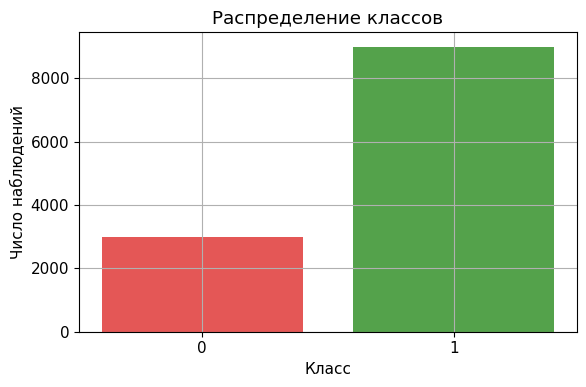

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = model_df[classification_target].value_counts().sort_index()
ax.bar(class_counts.index.astype(str), class_counts.values, color=["#e45756", "#54a24b"][:len(class_counts)])
ax.set_xlabel("Класс")
ax.set_ylabel("Число наблюдений")
ax.set_title("Распределение классов")
plt.tight_layout()
plt.show()


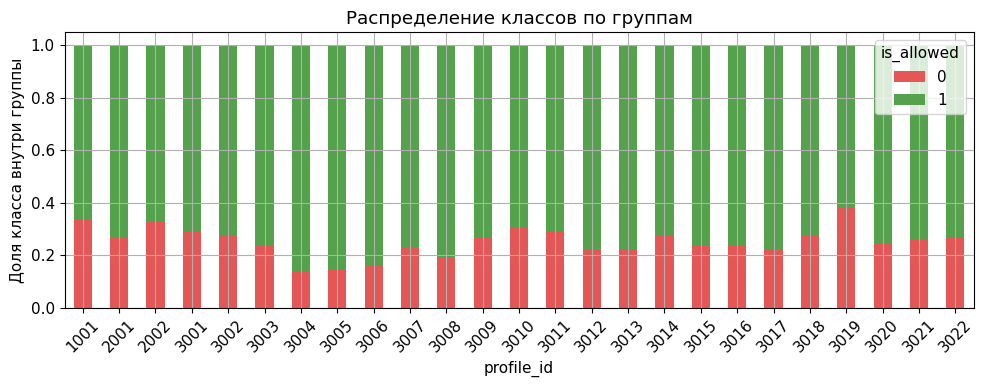

is_allowed,0,1
profile_id,,
1001,126,245
2001,133,367
2002,117,243
3001,145,355
3002,139,361
3003,120,380
3004,68,432
3005,74,426
3006,79,421


In [6]:
if GROUP_COLUMN in model_df.columns:
    class_by_group = (
        model_df.groupby([GROUP_COLUMN, classification_target])
        .size()
        .unstack(fill_value=0)
    )
    class_by_group_share = class_by_group.div(class_by_group.sum(axis=1), axis=0)
else:
    class_by_group_share = pd.DataFrame()

fig, ax = plt.subplots(figsize=(10, 4))
if not class_by_group_share.empty:
    class_by_group_share.head(40).plot(kind="bar", stacked=True, ax=ax, color=["#e45756", "#54a24b"])
    ax.set_ylabel("Доля класса внутри группы")
    ax.set_title("Распределение классов по группам")
    ax.tick_params(axis="x", rotation=45)
else:
    ax.text(0.5, 0.5, "Групповой столбец отсутствует", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

class_by_group.head(10) if GROUP_COLUMN in model_df.columns else "Групповой столбец отсутствует"


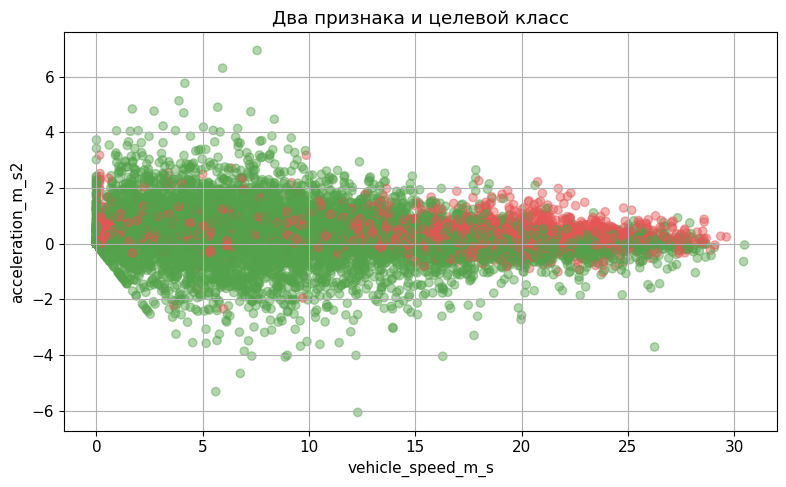

['vehicle_speed_m_s', 'acceleration_m_s2']

In [7]:
scatter_features = classification_features[:2]
if len(scatter_features) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = model_df[classification_target].map({0: "#e45756", 1: "#54a24b"})
    ax.scatter(
        model_df[scatter_features[0]],
        model_df[scatter_features[1]],
        c=colors,
        alpha=0.45,
    )
    ax.set_xlabel(scatter_features[0])
    ax.set_ylabel(scatter_features[1])
    ax.set_title("Два признака и целевой класс")
    plt.tight_layout()
    plt.show()
scatter_features


## Балансировка классов в дереве решений

Во внешних наборах данных доли классов часто различаются. Параметр
`class_weight="balanced"` увеличивает вклад редкого класса в критерий
обучения дерева. Это не гарантирует идеальную классификацию, но снижает риск
того, что модель будет оптимизировать только большинство и пропускать
критический класс. Небалансированные результаты следует рассматривать как
контрольный вариант, а не как основной режим для инженерной диагностики.


In [8]:
def classification_metrics(y_true, y_pred):
    cm_local = confusion_matrix(y_true, y_pred, labels=[0, 1])
    not_allowed_total = cm_local[0].sum()
    dangerous_false_allowed_rate = cm_local[0, 1] / not_allowed_total if not_allowed_total > 0 else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_not_allowed": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_not_allowed": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_not_allowed": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "dangerous_false_allowed_rate": dangerous_false_allowed_rate,
    }

majority_class = int(y_train.mode().iloc[0])
baseline_pred = np.full(len(y_test), majority_class, dtype=int)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

metrics_df = pd.DataFrame(
    [
        {"model": "majority_baseline", **classification_metrics(y_test, baseline_pred)},
        {"model": "strict_decision_tree", **classification_metrics(y_test, y_pred)},
    ]
).set_index("model")
metrics_df


,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
model,,,,,
majority_baseline,0.731722,0.000000,0.000000,0.000000,1.000000
strict_decision_tree,0.929948,0.820792,0.945268,0.878643,0.054732


In [9]:
interpret_classification_metrics(metrics_df)


Accuracy строгого дерева: 0.9299.
Recall недопустимого класса: 0.9453.
Доля ложных разрешений: 0.0547.
Интерпретация: для инженерной безопасности recall недопустимого класса и доля ложных разрешений важнее, чем одна общая accuracy.


In [10]:
random_train_idx, random_test_idx = train_test_split(
    model_df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=model_df[classification_target].astype(int),
)
random_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
random_tree.fit(
    model_df.loc[random_train_idx, classification_features],
    model_df.loc[random_train_idx, classification_target].astype(int),
)
random_pred = random_tree.predict(model_df.loc[random_test_idx, classification_features])

split_metrics = pd.DataFrame(
    [
        {"split_type": "group_holdout", **classification_metrics(y_test, y_pred)},
        {
            "split_type": "random_split",
            **classification_metrics(
                model_df.loc[random_test_idx, classification_target].astype(int),
                random_pred,
            ),
        },
    ]
).set_index("split_type")
split_metrics


,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
split_type,,,,,
group_holdout,0.929948,0.820792,0.945268,0.878643,0.054732
random_split,0.927667,0.802497,0.942667,0.866953,0.057333


In [11]:
if {"group_holdout", "random_split"}.issubset(split_metrics.index):
    delta_recall = (
        split_metrics.loc["random_split", "recall_not_allowed"]
        - split_metrics.loc["group_holdout", "recall_not_allowed"]
    )
    print(f"Разница random_split - group_holdout по recall недопустимого класса: {delta_recall:.4f}.")
    print(
        "Интерпретация: если случайное разбиение существенно лучше, необходимо "
        "проверить, не попали ли близкие наблюдения одной группы в обе части выборки."
    )


Разница random_split - group_holdout по recall недопустимого класса: -0.0026.
Интерпретация: если случайное разбиение существенно лучше, необходимо проверить, не попали ли близкие наблюдения одной группы в обе части выборки.


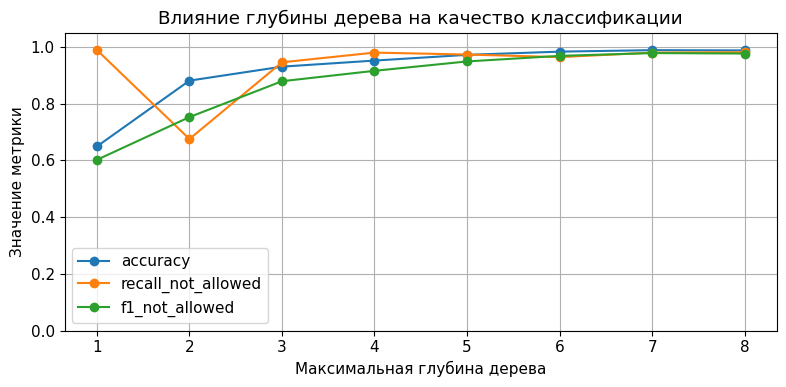

,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
max_depth,,,,,
1,0.648822,0.432419,0.988597,0.601666,0.011403
2,0.880697,0.849354,0.675029,0.752224,0.324971
3,0.929948,0.820792,0.945268,0.878643,0.054732
4,0.951361,0.859000,0.979475,0.915290,0.020525
5,0.971551,0.925163,0.972634,0.948305,0.027366
6,0.982869,0.972382,0.963512,0.967927,0.036488
7,0.988070,0.976136,0.979475,0.977803,0.020525
8,0.987152,0.971751,0.980616,0.976163,0.019384


In [12]:
depth_rows = []
for depth in range(1, 9):
    depth_model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    depth_model.fit(X_train, y_train)
    depth_pred = depth_model.predict(X_test)
    depth_rows.append({"max_depth": depth, **classification_metrics(y_test, depth_pred)})

depth_metrics_df = pd.DataFrame(depth_rows).set_index("max_depth")

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["accuracy", "recall_not_allowed", "f1_not_allowed"]:
    ax.plot(depth_metrics_df.index, depth_metrics_df[metric], marker="o", label=metric)
ax.set_xlabel("Максимальная глубина дерева")
ax.set_ylabel("Значение метрики")
ax.set_title("Влияние глубины дерева на качество классификации")
ax.set_ylim(0.0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

depth_metrics_df


In [13]:
interpret_depth_metrics(depth_metrics_df)


Наилучшая глубина по F1 недопустимого класса: 7.
Интерпретация: рост глубины увеличивает гибкость дерева, но может привести к переобучению. Следует выбирать не максимальную глубину, а глубину, которая дает приемлемый баланс качества и интерпретируемости.


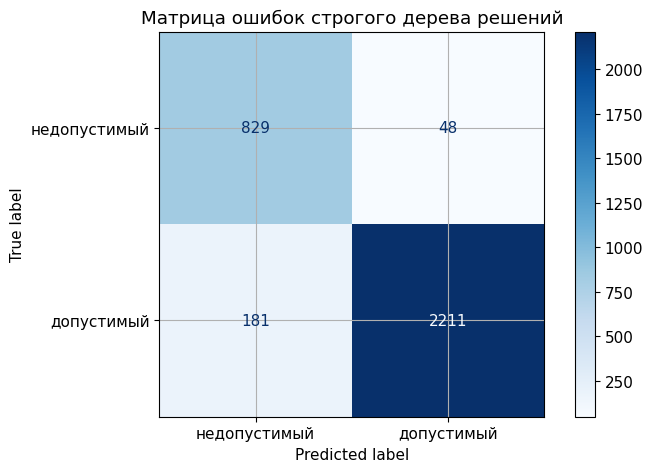

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["недопустимый", "допустимый"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Матрица ошибок строгого дерева решений")
plt.show()


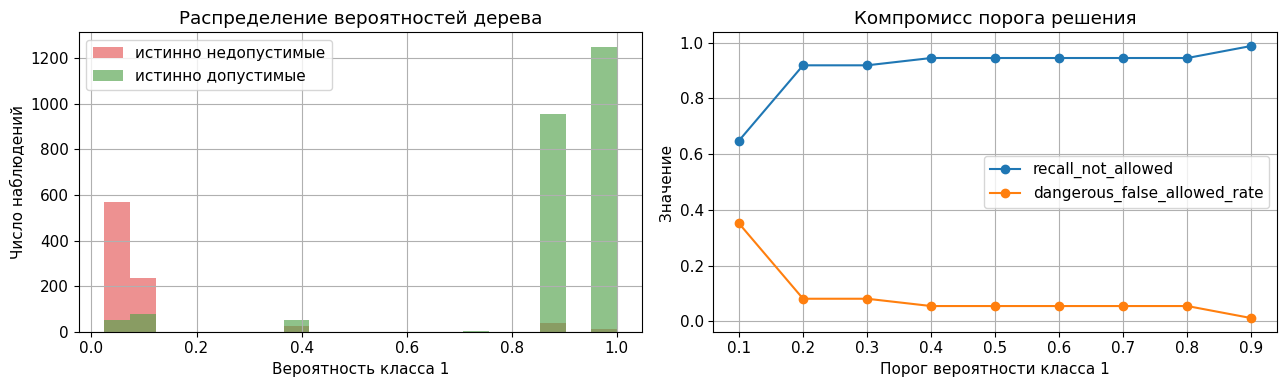

,threshold,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
0,0.1,0.889875,0.916264,0.648803,0.759680,0.351197
1,0.2,0.939125,0.862955,0.919042,0.890116,0.080958
2,0.3,0.939125,0.862955,0.919042,0.890116,0.080958
3,0.4,0.929948,0.820792,0.945268,0.878643,0.054732
4,0.5,0.929948,0.820792,0.945268,0.878643,0.054732
5,0.6,0.929948,0.820792,0.945268,0.878643,0.054732
6,0.7,0.929948,0.820792,0.945268,0.878643,0.054732
7,0.8,0.929030,0.818361,0.945268,0.877249,0.054732
8,0.9,0.647905,0.431773,0.988597,0.601040,0.011403


In [15]:
if hasattr(tree_model, "predict_proba"):
    allowed_probability = tree_model.predict_proba(X_test)[:, 1]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(allowed_probability[y_test == 0], bins=20, alpha=0.65, label="истинно недопустимые", color="#e45756")
    axes[0].hist(allowed_probability[y_test == 1], bins=20, alpha=0.65, label="истинно допустимые", color="#54a24b")
    axes[0].set_xlabel("Вероятность класса 1")
    axes[0].set_ylabel("Число наблюдений")
    axes[0].set_title("Распределение вероятностей дерева")
    axes[0].legend()

    threshold_rows = []
    for threshold in np.linspace(0.1, 0.9, 9):
        threshold_pred = (allowed_probability >= threshold).astype(int)
        threshold_rows.append({"threshold": threshold, **classification_metrics(y_test, threshold_pred)})
    threshold_metrics = pd.DataFrame(threshold_rows)
    axes[1].plot(threshold_metrics["threshold"], threshold_metrics["recall_not_allowed"], marker="o", label="recall_not_allowed")
    axes[1].plot(
        threshold_metrics["threshold"],
        threshold_metrics["dangerous_false_allowed_rate"],
        marker="o",
        label="dangerous_false_allowed_rate",
    )
    axes[1].set_xlabel("Порог вероятности класса 1")
    axes[1].set_ylabel("Значение")
    axes[1].set_title("Компромисс порога решения")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    threshold_metrics = pd.DataFrame()

threshold_metrics


In [16]:
if not threshold_metrics.empty:
    best_threshold = threshold_metrics.sort_values(
        ["dangerous_false_allowed_rate", "recall_not_allowed"],
        ascending=[True, False],
    ).iloc[0]
    print(
        "Интерпретация порога решения: уменьшение доли ложных разрешений может "
        "потребовать изменения порога вероятности класса 1. В выбранной сетке "
        f"минимальная доля ложных разрешений достигается при threshold={best_threshold['threshold']:.2f}."
    )


Интерпретация порога решения: уменьшение доли ложных разрешений может потребовать изменения порога вероятности класса 1. В выбранной сетке минимальная доля ложных разрешений достигается при threshold=0.90.


In [17]:
label_candidates = ["mode_label", "class_label", "fault_label", "fault_code"]
available_label_columns = [column for column in label_candidates if column in diagnostics_df.columns]

test_error_details = model_df.loc[test_idx, ["sample_id", classification_target]].copy()
test_error_details["true_class"] = y_test
test_error_details["predicted_class"] = y_pred
test_error_details["error_type"] = np.select(
    [
        (test_error_details["true_class"] == 0) & (test_error_details["predicted_class"] == 1),
        (test_error_details["true_class"] == 1) & (test_error_details["predicted_class"] == 0),
        test_error_details["true_class"] == test_error_details["predicted_class"],
    ],
    ["false_allowed", "false_blocked", "correct"],
    default="other",
)

if available_label_columns:
    test_error_details = test_error_details.merge(
        diagnostics_df[["sample_id"] + available_label_columns],
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
    summary_column = available_label_columns[0]
    error_summary = (
        test_error_details.groupby([summary_column, "error_type"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
else:
    error_summary = test_error_details["error_type"].value_counts().to_frame("count")

error_summary


error_type,correct,false_allowed,false_blocked
class_label,,,
acceptable_efficiency,2211,0,181
low_efficiency,829,48,0


In [18]:
print(
    "Интерпретация: сводка ошибок по диагностическим меткам показывает, какие "
    "физические или расчетные режимы модель путает чаще всего. Именно эти "
    "режимы следует обсуждать в инженерном выводе, а не только общую accuracy."
)


Интерпретация: сводка ошибок по диагностическим меткам показывает, какие физические или расчетные режимы модель путает чаще всего. Именно эти режимы следует обсуждать в инженерном выводе, а не только общую accuracy.


In [19]:
test_error_details.sort_values("error_type").head(15)


,sample_id,is_allowed,true_class,predicted_class,error_type,class_label
0,8732,1,1,1,correct,acceptable_efficiency
2130,10862,0,0,0,correct,low_efficiency
2131,10863,1,1,1,correct,acceptable_efficiency
2133,10865,1,1,1,correct,acceptable_efficiency
2134,10866,1,1,1,correct,acceptable_efficiency
2135,10867,1,1,1,correct,acceptable_efficiency
2136,10868,1,1,1,correct,acceptable_efficiency
2137,10869,1,1,1,correct,acceptable_efficiency
2138,10870,1,1,1,correct,acceptable_efficiency
2139,10871,1,1,1,correct,acceptable_efficiency


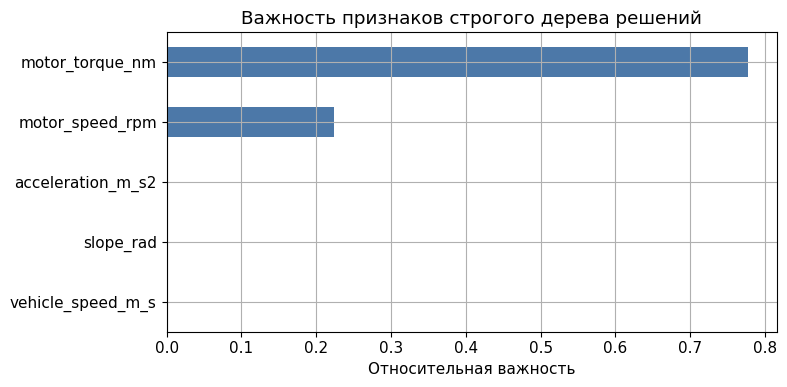

,importance
vehicle_speed_m_s,0.000000
slope_rad,0.000022
acceleration_m_s2,0.000328
motor_speed_rpm,0.223162
motor_torque_nm,0.776489


In [20]:
importance = pd.Series(tree_model.feature_importances_, index=classification_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_xlabel("Относительная важность")
ax.set_title("Важность признаков строгого дерева решений")
plt.tight_layout()
plt.show()
importance.to_frame("importance")


## Демонстрация риска утечки данных

> **Внимание. АНТИПРИМЕР - НЕ ИСПОЛЬЗОВАТЬ КАК РАБОЧУЮ МОДЕЛЬ.**
> Этот блок предназначен только для демонстрации утечки данных. Высокие
> метрики здесь показывают не качество модели, а некорректность набора
> признаков.

Если в классификацию включить столбцы, из которых непосредственно построена
целевая переменная, дерево будет воспроизводить правило разметки, а не решать
независимую прогностическую задачу.


In [21]:
leakage_features = [column for column in ['vehicle_speed_m_s', 'acceleration_m_s2', 'slope_rad', 'motor_speed_rpm', 'motor_torque_nm', 'motor_efficiency', 'drivetrain_efficiency'] if column in full_df.columns]
leakage_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=leakage_features + [classification_target]
).copy()
if len(leakage_features) >= 2 and leakage_df[classification_target].nunique() == 2:
    train_idx_l, test_idx_l, _ = group_holdout_split(
        leakage_df,
        GROUP_COLUMN,
        test_share=0.25,
        target_column=classification_target,
    )
    leakage_tree = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    leakage_tree.fit(leakage_df.loc[train_idx_l, leakage_features], leakage_df.loc[train_idx_l, classification_target].astype(int))
    leakage_pred = leakage_tree.predict(leakage_df.loc[test_idx_l, leakage_features])
    leakage_metrics = pd.Series(
        classification_metrics(leakage_df.loc[test_idx_l, classification_target].astype(int), leakage_pred),
        name="leakage_demo",
    )
else:
    leakage_metrics = pd.Series(dtype=float, name="leakage_demo")
leakage_metrics.to_frame("value")


,value
accuracy,1.0
precision_not_allowed,1.0
recall_not_allowed,1.0
f1_not_allowed,1.0
dangerous_false_allowed_rate,0.0


In [22]:
if not leakage_metrics.empty:
    strict_accuracy = metrics_df.loc["strict_decision_tree", "accuracy"]
    leakage_accuracy = leakage_metrics.get("accuracy", np.nan)
    print(f"Accuracy строгой модели: {strict_accuracy:.4f}.")
    print(f"Accuracy демонстрации утечки: {leakage_accuracy:.4f}.")
    print(
        "Интерпретация: если диагностические признаки резко улучшают качество, "
        "нужно проверить, не содержат ли они саму разметку или правило ее построения."
    )


Accuracy строгой модели: 0.9299.
Accuracy демонстрации утечки: 1.0000.
Интерпретация: если диагностические признаки резко улучшают качество, нужно проверить, не содержат ли они саму разметку или правило ее построения.


In [23]:
experiment_depth = 3
experiment_tree = DecisionTreeClassifier(
    max_depth=experiment_depth,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
experiment_tree.fit(X_train, y_train)
experiment_pred = experiment_tree.predict(X_test)
pd.Series(classification_metrics(y_test, experiment_pred), name="experiment")


accuracy                        0.929948
precision_not_allowed           0.820792
recall_not_allowed              0.945268
f1_not_allowed                  0.878643
dangerous_false_allowed_rate    0.054732
Name: experiment, dtype: float64

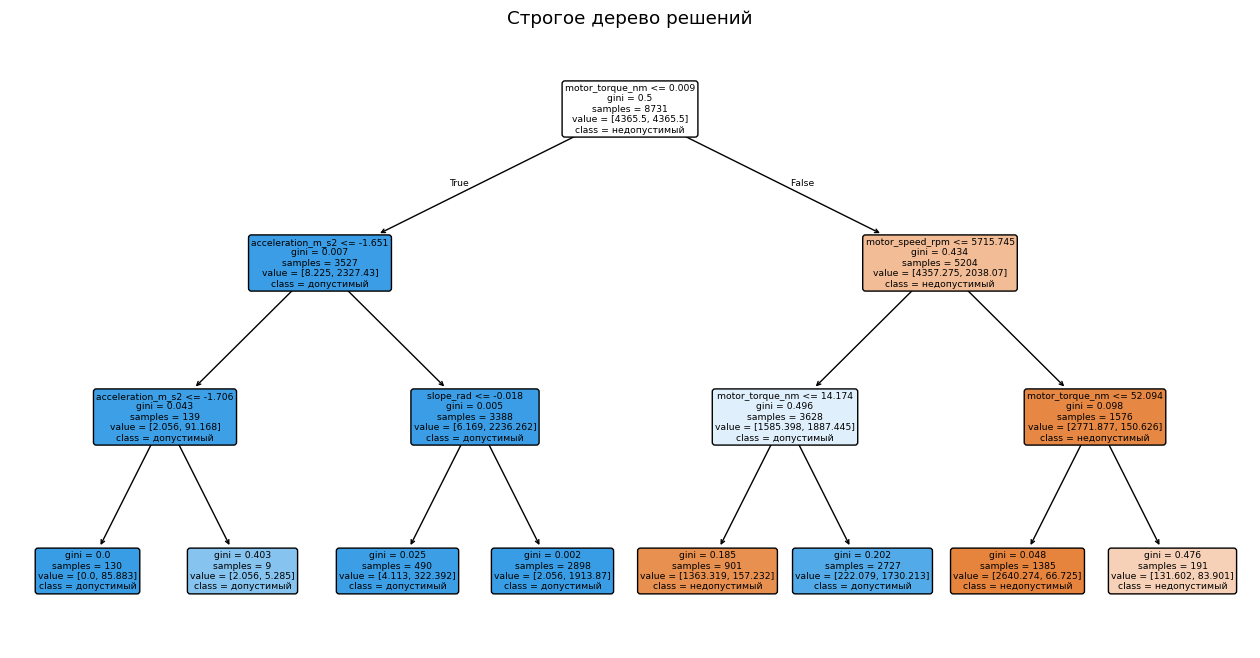

In [24]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=classification_features,
    class_names=["недопустимый", "допустимый"],
    filled=True,
    rounded=True,
    impurity=True,
)
plt.title("Строгое дерево решений")
plt.show()


## Типовые ошибки интерпретации

1. Оценивать дерево только по accuracy и не анализировать recall критического
   класса.
2. Использовать диагностическую метку отказа как обычный признак модели.
3. Увеличивать `max_depth` без анализа переобучения и объяснимости правил.
4. Записывать правила дерева без единиц измерения и физической интерпретации
   порога.

## Контрольные вопросы и мини-задания

1. Что означает класс 0 в данном блокноте и почему он критически важен?
2. Почему majority baseline может иметь приемлемую accuracy, но быть
   непригодным для диагностики?
3. Найдите глубину дерева с наилучшей F1-мерой критического класса и объясните
   компромисс между качеством и интерпретируемостью.
4. Измените `experiment_depth` и объясните, какие ошибки стали чаще или реже.
5. Выпишите одно правило дерева в инженерной форме: признак, порог, единица
   измерения и физический смысл.


## Задание

1. Укажите целевую переменную, кодировку классов и физический смысл класса 0.
2. Сравните дерево решений с базовой моделью большинства.
3. Постройте матрицу ошибок и рассчитайте долю ложных разрешений.
4. Выпишите 2-3 правила дерева в инженерной форме.
5. Объясните, какие признаки были исключены из-за риска утечки данных.
